In [3]:
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import re
import scipy
from scipy.stats import norm, linregress, pearsonr
from scipy.optimize import Bounds, LinearConstraint, minimize, SR1

import seaborn as sns
import sys
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, HTML
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, roc_curve, auc
from tqdm import tqdm 
pd.set_option('display.width', 1000)


In [ ]:
HDT = pd.read_csv('./outputs_in_manuscript/Real_participants_original_HDT.tsv', sep='\t')
HTT = pd.read_csv('./real_participants/average_merged_tasks.csv', usecols = ['Participant_ID', 'HTT_average_score', 'HTT_mean_confidence'])
S_HDT = pd.read_csv('./outputs_in_manuscript/Real_participant_pred_pss_accuracy_auc_conf.tsv', sep='\t')


# Rename columns (excluding the merge key)
S_HDT = S_HDT.add_prefix('S_HDT_').rename(columns={'S_HDT_Participant_ID': 'Participant_ID'})
HDT = HDT.rename(columns={'AUC': 'HDT_AUC'})

# Perform the merge
all_tasks = pd.merge(S_HDT, HDT, on='Participant_ID')
all_tasks = pd.merge(all_tasks, HTT, on='Participant_ID')
all_tasks = all_tasks.dropna()  # Drop rows with NaN values

# Display the result
display(HTML(all_tasks.to_html()))

all_tasks.to_csv('all_task_scores.csv', index=False) 


,Participant_ID,S_HDT_Pred_PSS_Value,S_HDT_Pred_Accuracy,S_HDT_RMSE_value,S_HDT_RMSE,S_HDT_AUC,S_HDT_Confidence,HDT_mean_confidence,HDT_overall_accuracy,AUC_x,AUC_y,HTT_average_score,HTT_mean_confidence


### Accuracy

C:\Users\hsavage\AppData\Local\Temp\ipykernel_5868\3901782704.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


<Figure size 1000x600 with 0 Axes>

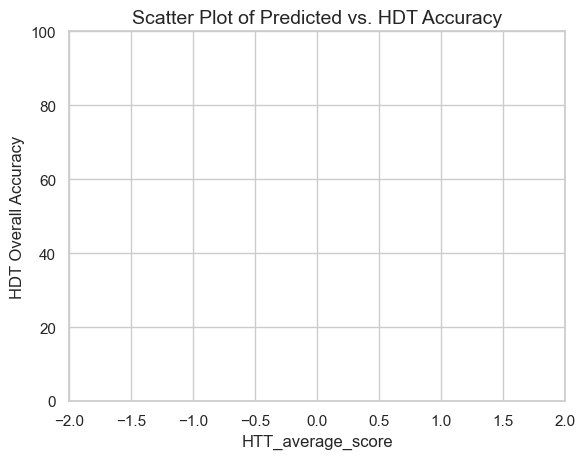

ValueError: x and y must have length at least 2.

In [9]:
# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()
#x = np.linspace(0, 60, 100)
#ax.fill_between(x, 0, 68, color='lightgrey', alpha=0.3)
scatter = sns.scatterplot(
    data = all_tasks,
    x='HTT_average_score', 
    y='HDT_overall_accuracy',
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    alpha=1.0,  
    legend = False)# Transparency for better visibility
    #edgecolor='black'       # Black edges for clarity

# Labels & title
plt.xlim(-2, 2)  # Correct: Use function calls
plt.ylim(0, 100)  # Correct: Use function calls

plt.xlabel('HTT_average_score', fontsize=12)
plt.ylabel('HDT Overall Accuracy', fontsize=12)
plt.title('Scatter Plot of Predicted vs. HDT Accuracy', fontsize=14)

# Adjust legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()

HDT_pearsonR_acc_HTT_acc = pearsonr(all_tasks['HDT_overall_accuracy'], all_tasks['HTT_average_score'])
print('Is HDT_overall_accuracy related to HTT_average_score? \n R =', HDT_pearsonR_acc_HTT_acc[0], '\n P-value:',HDT_pearsonR_acc_HTT_acc[1], '\n R2 = ', HDT_pearsonR_acc_HTT_acc[0]**2 )


Is S_HDT_Pred_Accuracy related to HDT_overall_accuracy? 
 R = -0.22784556155652863 
 P-value: 0.1688866429506363 
 R2 =  0.05191359992100988


<Figure size 1000x600 with 0 Axes>

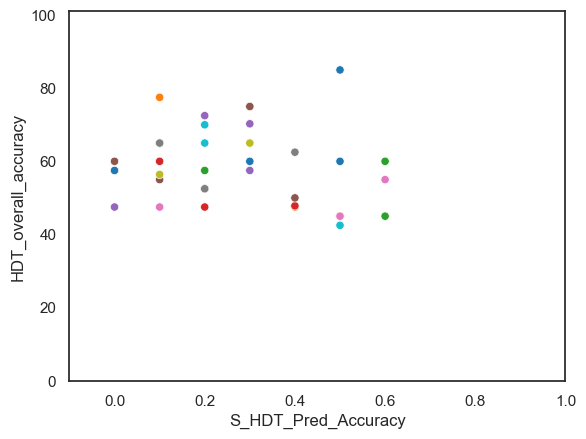

In [31]:
# Set plot style
sns.set(style="white")

# Create scatter plot 1
plt.figure(figsize=(10, 6))
norm = plt.Normalize(0, 1)
cbar_ticks = np.arange(0, 1.1, 0.1) 
fig, ax = plt.subplots()
scatter = sns.scatterplot(
    data=all_tasks, 
    x='S_HDT_Pred_Accuracy', 
    y='HDT_overall_accuracy',
    #size='Pred_PSS_Value',  # Scale dot size
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    color = 'red',
    alpha=1.0               # Transparency for better visibility
)
plt.xlim(-.1, 1.0)  
plt.ylim(-.1,101)

ax.legend_.remove()  # Remove legend

S_HDT_pearsonR_HDT_acc = pearsonr(all_tasks['S_HDT_Pred_Accuracy'], all_tasks['HDT_overall_accuracy'])
print('Is S_HDT_Pred_Accuracy related to HDT_overall_accuracy? \n R =', S_HDT_pearsonR_HDT_acc[0], '\n P-value:',S_HDT_pearsonR_HDT_acc[1], '\n R2 = ', S_HDT_pearsonR_HDT_acc[0]**2 )





Is S_HDT_Pred_Accuracy related to HTT_average_score? 
 R = -0.29961011552786965 
 P-value: 0.0676306471313425 
 R2 =  0.0897662213266234


<Figure size 1000x600 with 0 Axes>

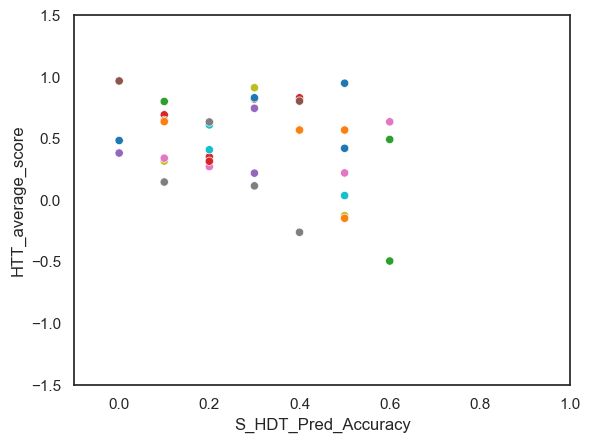

In [32]:
# Set plot style
sns.set(style="white")

# Create scatter plot 1
plt.figure(figsize=(10, 6))
norm = plt.Normalize(0, 1)
cbar_ticks = np.arange(0, 1.1, 0.1) 
fig, ax = plt.subplots()
scatter = sns.scatterplot(
    data=all_tasks, 
    x='S_HDT_Pred_Accuracy', 
    y='HTT_average_score',
    #size='Pred_PSS_Value',  # Scale dot size
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    color = 'red',
    alpha=1.0               # Transparency for better visibility
)
plt.xlim(-0.1, 1.0)  
plt.ylim(-1.5,1.5)

ax.legend_.remove()  # Remove legend

S_HDT_pearsonR_HTT_acc = pearsonr(all_tasks['S_HDT_Pred_Accuracy'], all_tasks['HTT_average_score'])
print('Is S_HDT_Pred_Accuracy related to HTT_average_score? \n R =', S_HDT_pearsonR_HTT_acc[0], '\n P-value:',S_HDT_pearsonR_HTT_acc[1], '\n R2 = ', S_HDT_pearsonR_HTT_acc[0]**2 )


### Confidence

<Figure size 1000x600 with 0 Axes>

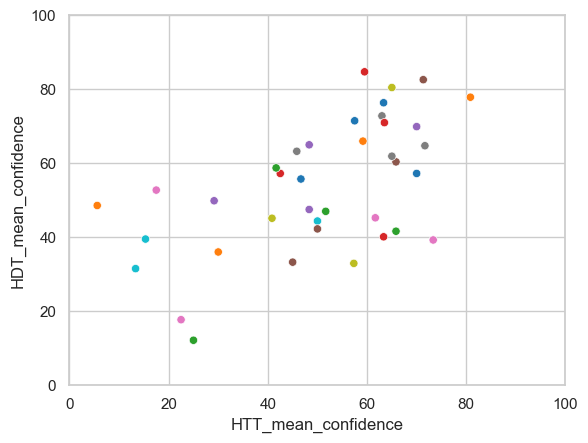

Is HTT_mean_confidence related to HDT_mean_confidence? 
 R = 0.5719213399489776 
 P-value: 0.00017601553589444765 
 R2 =  0.32709401908903407


In [43]:
# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()
#x = np.linspace(0, 60, 100)
#ax.fill_between(x, 0, 68, color='lightgrey', alpha=0.3)
scatter = sns.scatterplot(
    data = all_tasks,
    x='HTT_mean_confidence', 
    y='HDT_mean_confidence',
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    alpha=1.0,  
    legend = False)# Transparency for better visibility
    #edgecolor='black'       # Black edges for clarity

# Labels & title
plt.xlim(0,100)  # Correct: Use function calls
plt.ylim(0, 100)  # Correct: Use function calls

plt.xlabel('HTT_mean_confidence', fontsize=12)
plt.ylabel('HDT_mean_confidence', fontsize=12)

# Adjust legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()

HDT_pearsonR_conf_HTT_conf = pearsonr(all_tasks['HTT_mean_confidence'], all_tasks['HDT_mean_confidence'])
print('Is HTT_mean_confidence related to HDT_mean_confidence? \n R =', HDT_pearsonR_conf_HTT_conf[0], '\n P-value:',HDT_pearsonR_conf_HTT_conf[1], '\n R2 = ', HDT_pearsonR_conf_HTT_conf[0]**2 )


<Figure size 1000x600 with 0 Axes>

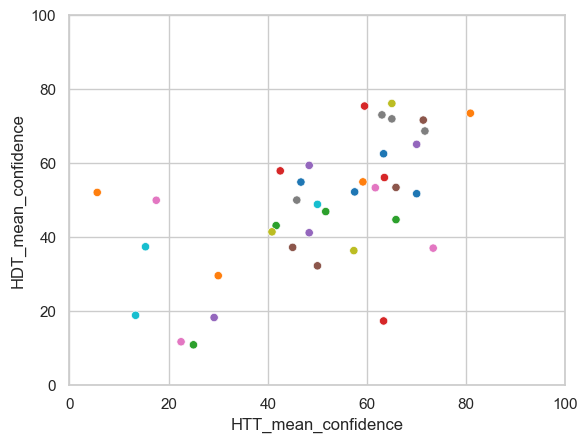

Is S_HTT_mean_confidence related to HDT_mean_confidence? 
 R = 0.5862910092957244 
 P-value: 0.00010974245320467182 
 R2 =  0.3437371475809992


In [46]:
# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()
#x = np.linspace(0, 60, 100)
#ax.fill_between(x, 0, 68, color='lightgrey', alpha=0.3)
scatter = sns.scatterplot(
    data = all_tasks,
    x='HTT_mean_confidence', 
    y='S_HDT_Confidence',
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    alpha=1.0,  
    legend = False)# Transparency for better visibility
    #edgecolor='black'       # Black edges for clarity

# Labels & title
plt.xlim(0,100)  # Correct: Use function calls
plt.ylim(0, 100)  # Correct: Use function calls

plt.xlabel('HTT_mean_confidence', fontsize=12)
plt.ylabel('HDT_mean_confidence', fontsize=12)

# Adjust legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()

S_HDT_pearsonR_conf_HTT_conf = pearsonr(all_tasks['HTT_mean_confidence'], all_tasks['S_HDT_Confidence'])
print('Is S_HDT_mean_confidence related to HDT_mean_confidence? \n R =', S_HDT_pearsonR_conf_HTT_conf[0], '\n P-value:',S_HDT_pearsonR_conf_HTT_conf[1], '\n R2 = ', S_HDT_pearsonR_conf_HTT_conf[0]**2 )


<Figure size 1000x600 with 0 Axes>

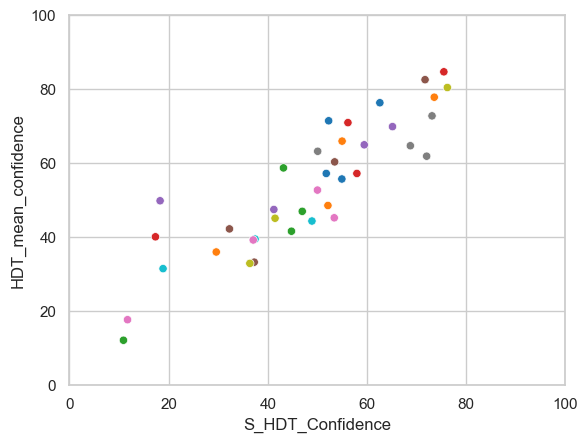

Is S_HDT_Confidence related to HDT_mean_confidence? 
 R = 0.8823901943444833 
 P-value: 2.4247983187022036e-13 
 R2 =  0.778612455075295


In [47]:
# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()
#x = np.linspace(0, 60, 100)
#ax.fill_between(x, 0, 68, color='lightgrey', alpha=0.3)
scatter = sns.scatterplot(
    data = all_tasks,
    x='S_HDT_Confidence', 
    y='HDT_mean_confidence',
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    alpha=1.0,  
    legend = False)# Transparency for better visibility
    #edgecolor='black'       # Black edges for clarity

# Labels & title
plt.xlim(0,100)  # Correct: Use function calls
plt.ylim(0, 100)  # Correct: Use function calls

plt.xlabel('S_HDT_Confidence', fontsize=12)
plt.ylabel('HDT_mean_confidence', fontsize=12)

# Adjust legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()

S_HDT_pearsonR_conf_HDT_conf = pearsonr(all_tasks['S_HDT_Confidence'], all_tasks['HDT_mean_confidence'])
print('Is S_HDT_Confidence related to HDT_mean_confidence? \n R =', S_HDT_pearsonR_conf_HDT_conf[0], '\n P-value:',S_HDT_pearsonR_conf_HDT_conf[1], '\n R2 = ', S_HDT_pearsonR_conf_HDT_conf[0]**2 )


### Insight

<Figure size 1000x600 with 0 Axes>

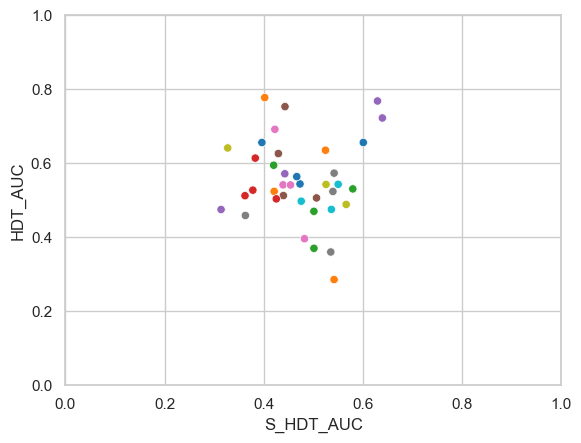

Is S_HDT_AUC related to HDT_AUC? 
 R = -0.008323167272972665 
 P-value: 0.9604456797608031 
 R2 =  6.927511345388323e-05


In [49]:
# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()
#x = np.linspace(0, 60, 100)
#ax.fill_between(x, 0, 68, color='lightgrey', alpha=0.3)
scatter = sns.scatterplot(
    data = all_tasks,
    x='S_HDT_AUC', 
    y='HDT_AUC',
    hue='Participant_ID',    # Color by participant
    palette='tab10',        # Distinct colors
    alpha=1.0,  
    legend = False)# Transparency for better visibility
    #edgecolor='black'       # Black edges for clarity

# Labels & title
plt.xlim(0, 1)  # Correct: Use function calls
plt.ylim(0, 1)  # Correct: Use function calls

plt.xlabel('S_HDT_AUC', fontsize=12)
plt.ylabel('HDT_AUC', fontsize=12)

# Adjust legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()

S_HDT_pearsonR_AUC_HDT_AUC = pearsonr(all_tasks['S_HDT_AUC'], all_tasks['HDT_AUC'])
print('Is S_HDT_AUC related to HDT_AUC? \n R =', S_HDT_pearsonR_AUC_HDT_AUC[0], '\n P-value:',S_HDT_pearsonR_AUC_HDT_AUC[1], '\n R2 = ', S_HDT_pearsonR_AUC_HDT_AUC[0]**2 )
